In [9]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pickle
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
# ============================
# 1. Konfigurasi (sesuaikan)
# ============================
DATA_DIR = '../data_clean'          # path dataset
IMG_SIZE = (224, 224)
TEST_SIZE = 0.15
RANDOM_SEED = 42
BATCH_SIZE = 32
OUTPUT_DIR = '../results_kfold'

In [11]:

# 1. Load dataset (sama seperti saat training)
def load_images_from_folder(data_dir, img_size):
    images = []
    labels = []
    file_paths = [] 
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        for fname in os.listdir(class_path):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            img_path = os.path.join(class_path, fname) 
            img = cv2.imread(os.path.join(class_path, fname))
            if img is not None:
                img = cv2.resize(img, img_size)
                images.append(img)
                labels.append(class_name)
                file_paths.append(img_path)
    return np.array(images), np.array(labels), np.array(file_paths) 

X, y_str, file_paths = load_images_from_folder(DATA_DIR, IMG_SIZE)
le = LabelEncoder()
y = le.fit_transform(y_str)

# Split ulang dengan seed yang sama
X_temp, X_test, y_temp, y_test, paths_temp, paths_test = train_test_split(
    X, y, file_paths, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_SEED
)
print(f"Test set: {len(X_test)} gambar")

Test set: 1500 gambar


In [12]:
# 2. Muat model terbaik
with open(os.path.join(OUTPUT_DIR, 'all_results.pkl'), 'rb') as f:
    results = pickle.load(f)
best_model_path = results['best_model_path']
best_model = tf.keras.models.load_model(best_model_path)

In [13]:
# 3. Prediksi pada test set
test_datagen = ImageDataGenerator(rescale=1./255)
y_test_cat = tf.keras.utils.to_categorical(y_test, 2)
test_gen = test_datagen.flow(X_test, y_test_cat, batch_size=BATCH_SIZE, shuffle=False)
y_pred = np.argmax(best_model.predict(test_gen), axis=1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 36s 725ms/step


In [14]:
# 4. Cari False Negative (TB → Normal)
fn_idx = np.where((y_test == 1) & (y_pred == 0))[0]
print(f"Jumlah False Negative: {len(fn_idx)}")

Jumlah False Negative: 1


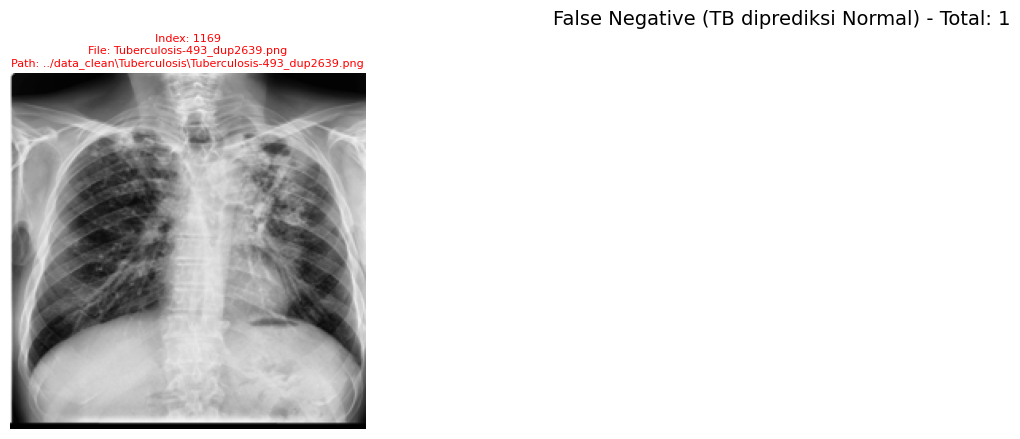


=== Daftar path file False Negative ===
../data_clean\Tuberculosis\Tuberculosis-493_dup2639.png


In [15]:
# 5. Tampilkan gambar FN dengan nama file dan path
if len(fn_idx) > 0:
    num_show = min(12, len(fn_idx))
    plt.figure(figsize=(16, 12))
    for i, idx in enumerate(fn_idx[:num_show]):
        plt.subplot(3, 4, i+1)
        img = X_test[idx].astype('uint8')
        plt.imshow(img)
        
        # Ambil path file dari paths_test
        file_path = paths_test[idx]
        plt.title(
            f'Index: {idx}\nFile: {os.path.basename(file_path)}\nPath: {file_path}',
            color='red',
            fontsize=8
        )
        plt.axis('off')
    plt.suptitle(f'False Negative (TB diprediksi Normal) - Total: {len(fn_idx)}', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'false_negative_samples_with_path.png'))
    plt.show()
    
    # Cetak daftar path ke console agar mudah di-copy
    print("\n=== Daftar path file False Negative ===")
    for idx in fn_idx:
        print(paths_test[idx])
else:
    print("Tidak ada False Negative pada test set.")